### Model Creation

OPTIMIZED MODEL OUTPUT (REGULAR SEASON)
Optimal F1 Threshold: 0.1213
Accuracy:    0.6846
Sensitivity: 0.7516
Specificity: 0.6785
Confusion Matrix: TN=1169, FP=554, FN=39, TP=118


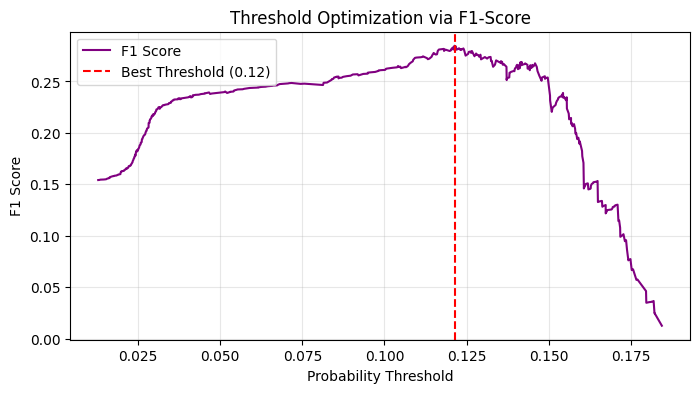

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

# 1. LOAD AND PREPARE DATA
df = pd.read_csv('NHL_Goalie_Pull_Detailed_Analysis.csv')

# Filter for Regular Season only ('02' in the GameID)
df = df[df['GameID'].astype(str).str[4:6] == '02']

cat_features = ['Zone_At_Start', 'Pull_Occurred_During']
num_features = ['Is_Home_Team', 'Seconds_Remaining_At_Pull', 'Score_When_Pulled', 'Is_Powerplay_Pull']
target = 'Did_Successfully_Tie'

# Clean and Dummy Encode
df_clean = df.dropna(subset=cat_features + num_features + [target])
X = pd.get_dummies(df_clean[num_features + cat_features], columns=cat_features, drop_first=True)
y = df_clean[target]

# 2. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. INITIAL MODEL TRAINING
model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=50, random_state=42)
model.fit(X_train, y_train)

# 4. FIND OPTIMAL F1 THRESHOLD
y_prob = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate F1 for each threshold (handle division by zero if necessary)
f1_scores = np.divide(2 * (precision[:-1] * recall[:-1]),
                      (precision[:-1] + recall[:-1]),
                      out=np.zeros_like(thresholds),
                      where=(precision[:-1] + recall[:-1]) != 0)

# Identify the best threshold
best_idx = np.argmax(f1_scores)
custom_threshold = thresholds[best_idx]

# 5. CALCULATE FINAL METRICS USING OPTIMAL THRESHOLD
y_pred_custom = (y_prob >= custom_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

# 6. OUTPUT RESULTS
print("="*40)
print(f"OPTIMIZED MODEL OUTPUT (REGULAR SEASON)")
print("="*40)
print(f"Optimal F1 Threshold: {custom_threshold:.4f}")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("="*40)

# Optional Visual: F1 Curve
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='purple', label='F1 Score')
plt.axvline(custom_threshold, color='red', linestyle='--', label=f'Best Threshold ({custom_threshold:.2f})')
plt.title('Threshold Optimization via F1-Score')
plt.xlabel('Probability Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Feature Importance

/tmp/ipykernel_3794/284388499.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


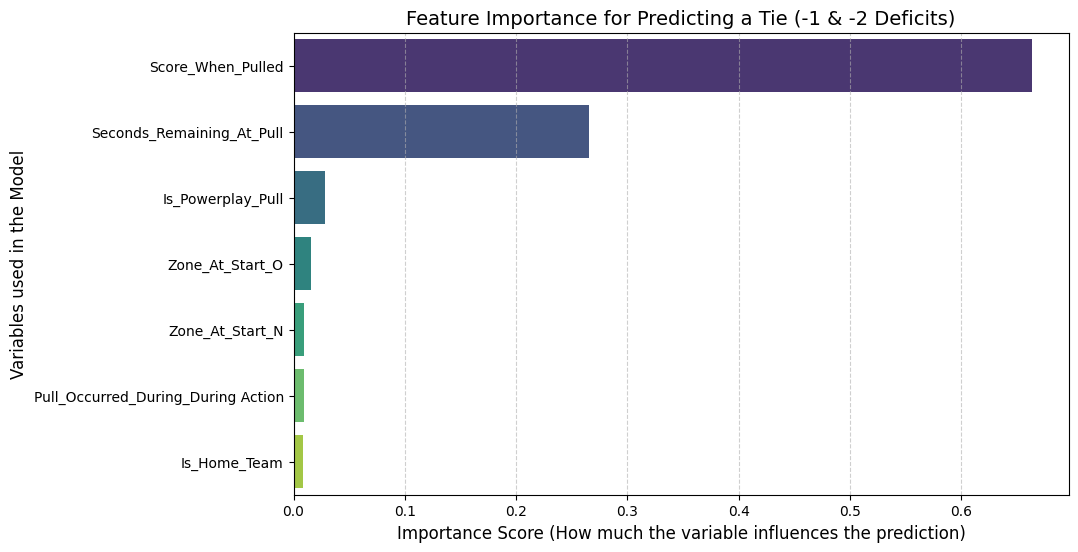

In [ ]:
# 1. Extract Feature Importances
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. Create the Visual
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')

plt.title('Feature Importance for Predicting a Tie (-1 & -2 Deficits)', fontsize=14)
plt.xlabel('Importance Score (How much the variable influences the prediction)', fontsize=12)
plt.ylabel('Variables used in the Model', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()

### When should I pull the goalie


   NHL GOALIE PULL DECISION AUDITOR
Is the team Home? (1 for Yes, 0 for No): 1
Score deficit? (e.g., -1 or -2): -2
On a Powerplay? (1 for Yes, 0 for No): 1
Starting Zone? (O=Offensive, N=Neutral, D=Defensive): O
Pull during live action? (1 for Yes, 0 for Faceoff/Whistle): 0
At what time (in seconds remaining) will you pull the goalie?: 120

----------------------------------------
MATHEMATICAL OPTIMUM: 1m 40s (5.81%)
YOUR CHOSEN PULL:    2m 0s (4.24%)
PROBABILITY LOSS:     1.58%
----------------------------------------
STRATEGY: [HOLD] Your choice is below the 12.1% F1-Threshold.
----------------------------------------


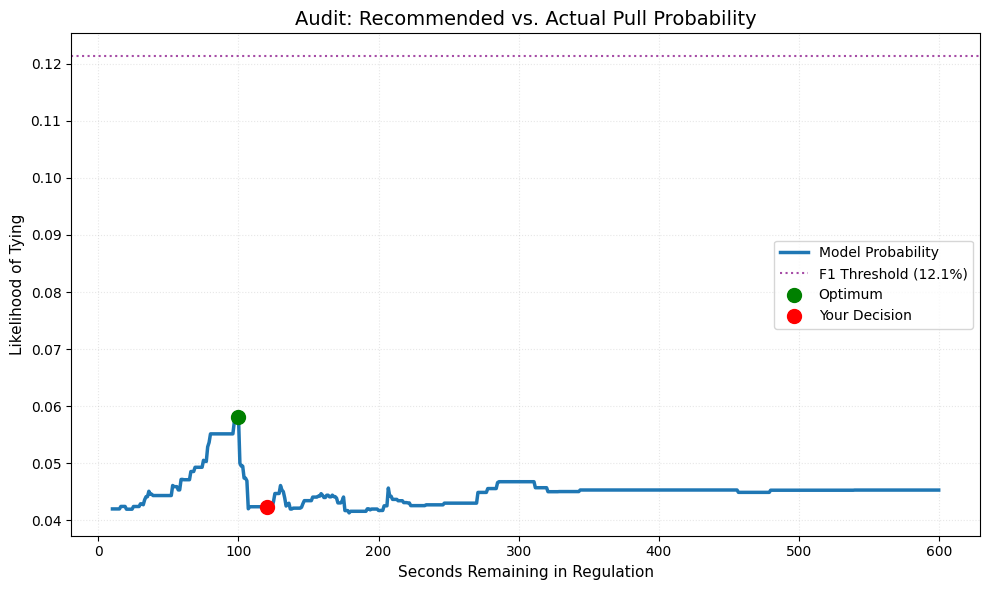

In [ ]:
# --- 1. COLLECT GAME-STATE & USER DECISION ---
print("\n" + "="*40)
print("   NHL GOALIE PULL DECISION AUDITOR")
print("="*40)

is_home = int(input("Is the team Home? (1 for Yes, 0 for No): "))
score_diff = int(input("Score deficit? (e.g., -1 or -2): "))
is_pp = int(input("On a Powerplay? (1 for Yes, 0 for No): "))
zone = input("Starting Zone? (O=Offensive, N=Neutral, D=Defensive): ").upper()
is_action = int(input("Pull during live action? (1 for Yes, 0 for Faceoff/Whistle): "))

# NEW INPUT: Your specific decision
user_seconds = int(input("At what time (in seconds remaining) will you pull the goalie?: "))

# --- 2. BUILD THE SIMULATION DATA ---
test_times = np.arange(10, 601, 1)
zone_o = 1 if zone == 'O' else 0
zone_n = 1 if zone == 'N' else 0

sim_data = pd.DataFrame({
    'Is_Home_Team': [is_home] * len(test_times),
    'Seconds_Remaining_At_Pull': test_times,
    'Score_When_Pulled': [score_diff] * len(test_times),
    'Is_Powerplay_Pull': [is_pp] * len(test_times),
    'Zone_At_Start_N': [zone_n] * len(test_times),
    'Zone_At_Start_O': [zone_o] * len(test_times),
    'Pull_Occurred_During_During Action': [is_action] * len(test_times)
})

sim_data = sim_data[X.columns]

# --- 3. GET PROBABILITIES ---
probs = model.predict_proba(sim_data)[:, 1]

opt_idx = np.argmax(probs)
opt_seconds = test_times[opt_idx]
peak_prob = probs[opt_idx]

user_idx = np.abs(test_times - user_seconds).argmin()
user_prob = probs[user_idx]

# --- 4. OUTPUT THE AUDIT WITH THRESHOLD LOGIC ---
print(f"\n" + "-"*40)
print(f"MATHEMATICAL OPTIMUM: {opt_seconds // 60}m {opt_seconds % 60}s ({peak_prob:.2%})")
print(f"YOUR CHOSEN PULL:    {user_seconds // 60}m {user_seconds % 60}s ({user_prob:.2%})")
print(f"PROBABILITY LOSS:     {peak_prob - user_prob:.2%}")
print(f"-"*40)

# Decision Recommendation based on the new F1 Threshold (0.1213)
if user_prob >= custom_threshold:
    print(f"STRATEGY: [GO] Your choice exceeds the {custom_threshold:.1%} F1-Threshold.")
else:
    print(f"STRATEGY: [HOLD] Your choice is below the {custom_threshold:.1%} F1-Threshold.")
print("-"*40)

# --- 5. VISUALIZE THE COMPARISON ---
plt.figure(figsize=(10, 6))
plt.plot(test_times, probs, color='#1f77b4', linewidth=2.5, label='Model Probability')

# Add the Threshold Line visually
plt.axhline(y=custom_threshold, color='purple', linestyle=':', alpha=0.7, label=f'F1 Threshold ({custom_threshold:.1%})')

# Highlight the optimum in Green and choice in Red
plt.scatter([opt_seconds], [peak_prob], color='green', s=100, zorder=5, label='Optimum')
plt.scatter([user_seconds], [user_prob], color='red', s=100, zorder=5, label='Your Decision')

plt.title(f'Audit: Recommended vs. Actual Pull Probability', fontsize=14)
plt.xlabel('Seconds Remaining in Regulation', fontsize=11)
plt.ylabel('Likelihood of Tying', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Goalie Pull Cheat Sheet

In [ ]:
from IPython.display import display

# Variables to iterate through ALL predictors
home_status = [1, 0]
deficits = [-1, -2]
powerplays = [1, 0]
zones = ['O', 'N', 'D']
actions = [1, 0]

results = []

for home in home_status:
    for score in deficits:
        for pp in powerplays:
            for z in zones:
                for action in actions:

                    zone_o = 1 if z == 'O' else 0
                    zone_n = 1 if z == 'N' else 0

                    temp_sim = pd.DataFrame({
                        'Is_Home_Team': [home] * len(test_times),
                        'Seconds_Remaining_At_Pull': test_times,
                        'Score_When_Pulled': [score] * len(test_times),
                        'Is_Powerplay_Pull': [pp] * len(test_times),
                        'Zone_At_Start_N': [zone_n] * len(test_times),
                        'Zone_At_Start_O': [zone_o] * len(test_times),
                        'Pull_Occurred_During_During Action': [action] * len(test_times)
                    })

                    temp_sim = temp_sim[X.columns]

                    probs = model.predict_proba(temp_sim)[:, 1]
                    best_idx = np.argmax(probs)
                    opt_sec = test_times[best_idx]

                    results.append({
                        'Venue': 'Home' if home == 1 else 'Away',
                        'Deficit': score,
                        'PP': 'Yes' if pp == 1 else 'No',
                        'Zone': 'Off' if z == 'O' else ('Neut' if z == 'N' else 'Def'),
                        'Context': 'Action' if action == 1 else 'Whistle',
                        'Optimal Pull Time': f"{opt_sec // 60}m {opt_sec % 60}s",
                        'Success Prob %': round(probs[best_idx] * 100, 2)
                    })

# 1. Convert to DataFrame
full_matrix_df = pd.DataFrame(results)

# 2. SORT the DataFrame by Success Prob % (Descending)
full_matrix_df = full_matrix_df.sort_values(by='Success Prob %', ascending=False)

# 3. Apply Styling
styled_full_matrix = full_matrix_df.style.background_gradient(subset=['Success Prob %'], cmap='RdYlGn') \
    .set_caption("RANKED NHL GOALIE PULL STRATEGIES (Highest to Lowest Success Probability)") \
    .set_properties(**{'text-align': 'center', 'border': '1px solid #ddd', 'font-size': '10pt'}) \
    .hide(axis="index")

display(styled_full_matrix)

Venue,Deficit,PP,Zone,Context,Optimal Pull Time,Success Prob %
Away,-1,Yes,Off,Action,1m 57s,18.650000
Home,-1,Yes,Off,Action,1m 40s,18.450000
Away,-1,Yes,Off,Whistle,1m 57s,17.950000
Away,-1,No,Off,Whistle,1m 57s,17.670000
Away,-1,No,Off,Action,1m 57s,17.570000
Home,-1,Yes,Off,Whistle,2m 7s,16.900000
Home,-1,No,Off,Action,2m 7s,16.620000
Home,-1,No,Off,Whistle,2m 7s,15.950000
Home,-1,Yes,Def,Action,1m 40s,14.550000
Away,-1,Yes,Def,Action,1m 57s,14.370000


### EXPLORATORY DATA ANALYSIS

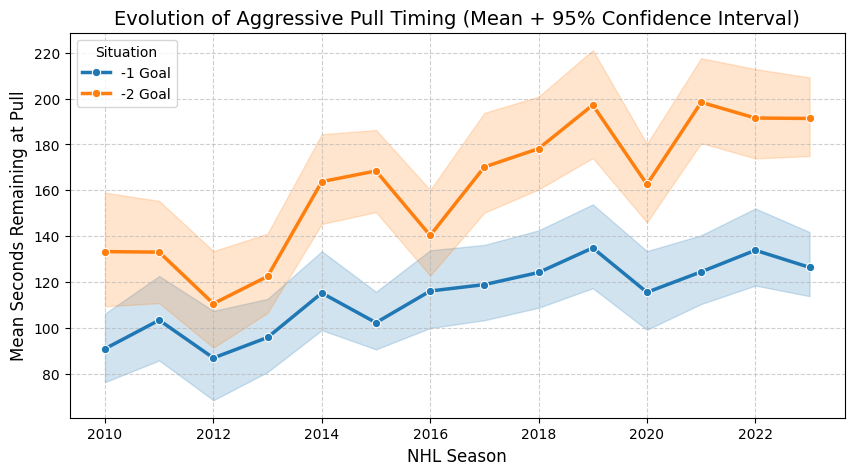

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD AND PREPARE DATA
df = pd.read_csv('NHL_Goalie_Pull_Detailed_Analysis.csv')

# Filter for Regular Season only
df = df[df['GameID'].astype(str).str[4:6] == '02'].copy()

# Create Season column
df['Season'] = df['GameID'].astype(str).str[:4].astype(int)

# Filter for -1 and -2 deficits only
df_filtered = df[df['Score_When_Pulled'].isin([-1, -2])].copy()

# Create a cleaner label for the legend
df_filtered['Goal_Deficit'] = df_filtered['Score_When_Pulled'].astype(str) + " Goal"

# --- VISUAL 1: Timing Evolution (Mean + 95% CI) ---
plt.figure(figsize=(10, 5))
# Note: We pass the raw df_filtered so Seaborn can calculate the Mean and CI
sns.lineplot(data=df_filtered, x='Season', y='Seconds_Remaining_At_Pull',
             hue='Goal_Deficit', marker='o', linewidth=2.5,
             estimator='mean', errorbar=('ci', 95))

plt.title('Evolution of Aggressive Pull Timing (Mean + 95% Confidence Interval)', fontsize=14)
plt.xlabel('NHL Season', fontsize=12)
plt.ylabel('Mean Seconds Remaining at Pull', fontsize=12)
plt.legend(title='Situation')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('timing_evolution_ci.png')
plt.show()

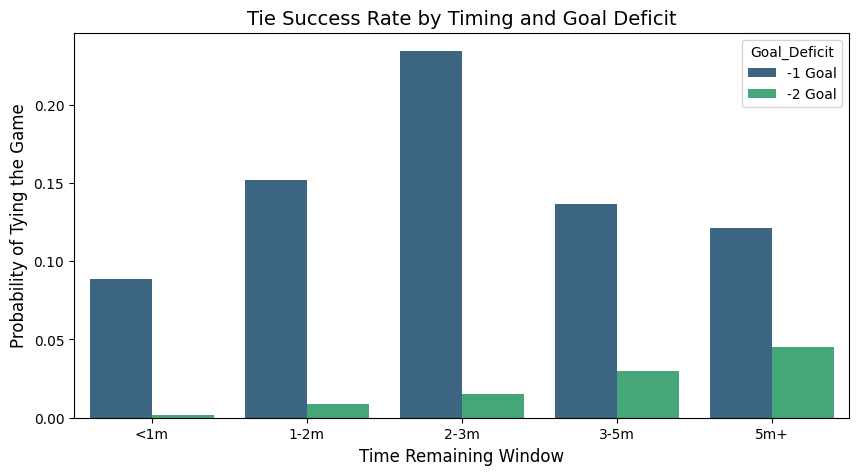

In [ ]:
# --- VISUAL 2: Tie Success Rate vs. Timing (Hue by Deficit) ---
df_filtered['Time_Bin'] = pd.cut(df_filtered['Seconds_Remaining_At_Pull'],
                                 bins=[0, 60, 120, 180, 300, 1200],
                                 labels=['<1m', '1-2m', '2-3m', '3-5m', '5m+'])
success_time = df_filtered.groupby(['Time_Bin', 'Goal_Deficit'], observed=False)['Did_Successfully_Tie'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=success_time, x='Time_Bin', y='Did_Successfully_Tie', hue='Goal_Deficit', palette='viridis')
plt.title('Tie Success Rate by Timing and Goal Deficit', fontsize=14)
plt.ylabel('Probability of Tying the Game', fontsize=12)
plt.xlabel('Time Remaining Window', fontsize=12)
plt.show()

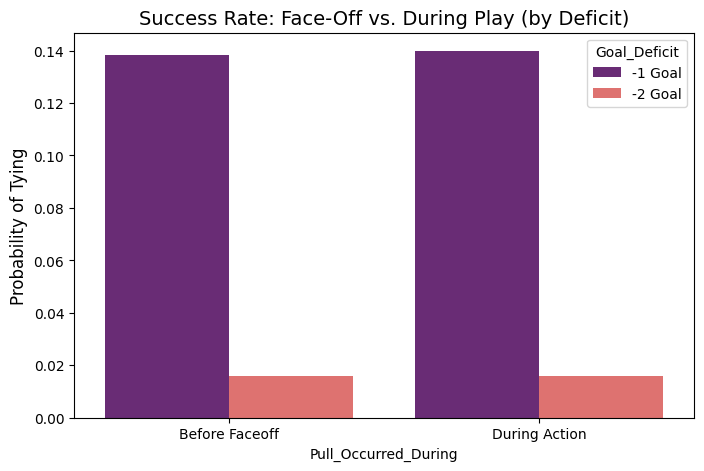

In [ ]:
# --- VISUAL 3: Face-Off vs. During Play Success (Hue by Deficit) ---
success_context = df_filtered.groupby(['Pull_Occurred_During', 'Goal_Deficit'])['Did_Successfully_Tie'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=success_context, x='Pull_Occurred_During', y='Did_Successfully_Tie', hue='Goal_Deficit', palette='magma')
plt.title('Success Rate: Face-Off vs. During Play (by Deficit)', fontsize=14)
plt.ylabel('Probability of Tying', fontsize=12)
plt.show()

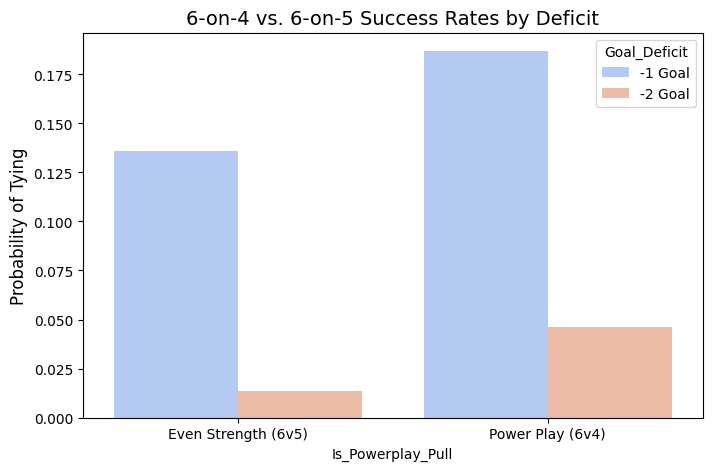

In [ ]:
# --- VISUAL 4: The Power Play Advantage (Hue by Deficit) ---
success_pp = df_filtered.groupby(['Is_Powerplay_Pull', 'Goal_Deficit'])['Did_Successfully_Tie'].mean().reset_index()
success_pp['Is_Powerplay_Pull'] = success_pp['Is_Powerplay_Pull'].map({0: 'Even Strength (6v5)', 1: 'Power Play (6v4)'})

plt.figure(figsize=(8, 5))
sns.barplot(data=success_pp, x='Is_Powerplay_Pull', y='Did_Successfully_Tie', hue='Goal_Deficit', palette='coolwarm')
plt.title('6-on-4 vs. 6-on-5 Success Rates by Deficit', fontsize=14)
plt.ylabel('Probability of Tying', fontsize=12)
plt.show()

In [ ]:
df.describe()

,GameID,Is_Home_Team,Seconds_Remaining_At_Pull,Score_When_Pulled,Final_Score_Differential,Score_Change,Goals_Scored,Empty_Net_Goals_Against,Is_Powerplay_Pull,Did_Successfully_Tie,Outcome_Class,Season
count,9.404000e+03,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000,9404.000000
mean,2.016780e+09,0.477669,153.170140,-1.566780,-1.462037,0.104743,0.196087,0.091344,0.072522,0.081136,0.093790,2016.759677
std,4.011356e+06,0.499528,187.838279,0.708876,0.808301,0.499476,0.438547,0.297198,0.259365,0.273058,0.461339,4.011348
min,2.010020e+09,0.000000,0.000000,-7.000000,-7.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,2010.000000
25%,2.014020e+09,0.000000,64.000000,-2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000
50%,2.017020e+09,0.000000,99.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000
75%,2.020021e+09,1.000000,153.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2020.000000
max,2.023021e+09,1.000000,1200.000000,-1.000000,1.000000,3.000000,3.000000,3.000000,1.000000,1.000000,1.000000,2023.000000
